<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo de Laboratorio Nº2
#### Grupo Nº1
#### Federico Borello, Facundo Farcy, Gabriel Barale

## Consigna

- Consolidar los conceptos de los sistemas muestreados mediante el uso de ADC y DACs.
- Simular e implementar un filtro digital con el STM NUCLEO-64.
- Familiarizarse con el uso de librerías para procesamiento digital de señales.
- Medir las partes de la función transferencia H[z] para frecuencias entre 10 Hz y 10 kHz.

Se parte a partir de los diseños de filtros analógicos realizados la TS9, y se implementan versiones digitales de los mismos utilizando técnicas de diseño FIR e IIR.

<div align=center>

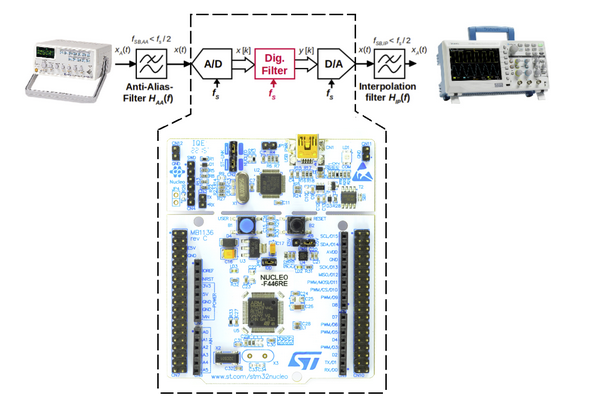

</div>

Se utiliza un STM32 NUCLEO-64 como plataforma de desarrollo, y se programa utilizando la librería CMSIS-DSP para el procesamiento digital de señales. Especificamente, se utilizan las funciones de filtrado FIR e IIR provistas por la librería:

- `arm_fir_f32`
- `arm_biquad_cascade_df1_f32`


El conexionado del sistema es el siguiente:

<div align=center>

|  #PIN  |    Descripción    |
|:------:|:-----------------:|
|   CN6 - pin6    |  GND  |
|   CN6 - pin4    |   VCC   |
|   CN8 - pin1    |  ADC_IN |
|   CN8 - pin3    |  DAC_OUT  |

</div>

A la entrada y salida se utilizan filtros analógicos pasa bajos de primer orden con frecuencia de corte en $500 [Hz]$ para evitar aliasing y suavizar la señal respectivamente.

In [1]:
# SetUp - Import /utils module
import sys
import os

sys.path.append(os.path.abspath(".."))
import utils.plot as uplt
import utils.synth as usynth

# Import common packages
from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import pandas as pd
from pytc2.sistemas_lineales import plot_plantilla

# Síntesis - RC Pasa Bajos


### Valor numérico normalizado:
$$C = 1.00$$
### Valor numérico de $R$ seteando $C = 10 nF$ y $\omega_n \omega_0 = 3141.59[rad/s]$:
$$R = 31.8 k\Omega$$
### Verificación de resultados ($C = \frac{C_{\text{normalizado}}}{\omega_0 \; \omega_n \; \Omega_Z}$):
$$C = 10 nF$$


$$H(s) = 3.14E^{3} \frac{1}{1s + 3.14E^{3}}$$

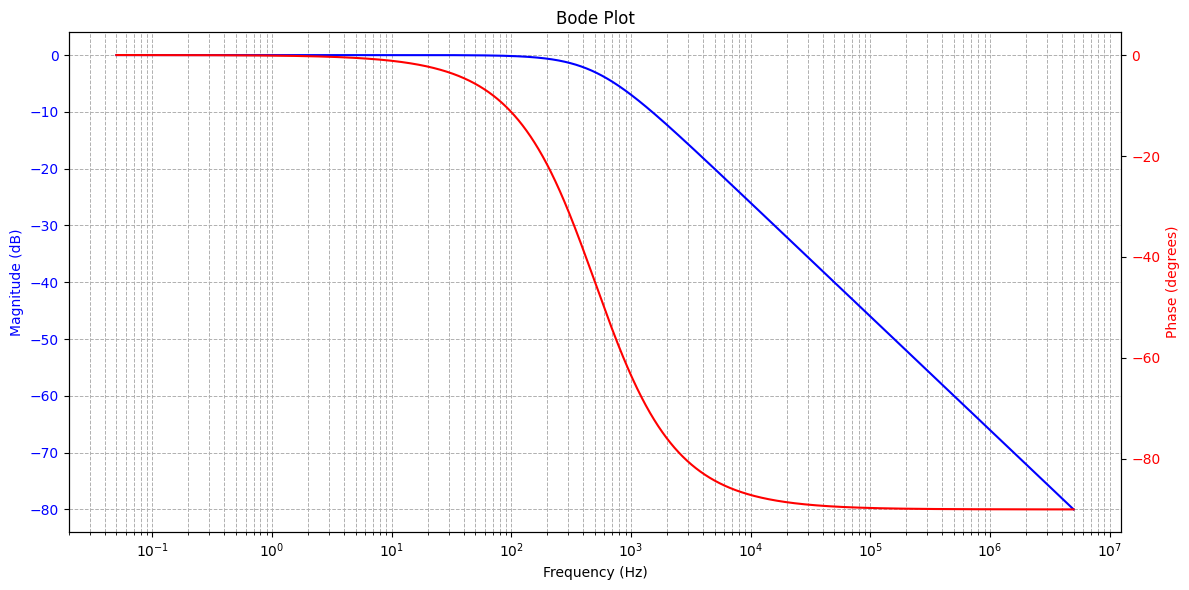

In [2]:
f = 500
_w0 = 500 * 2 * np.pi

T1_eval = usynth.synth_RC(_w0)
usynth.get_values_RC(_w0, C_forced=10e-9)

_ = uplt.plot_tf(T1_eval, {}, f_center=500)

# Análisis en Laboratorio

- Tensión de alimentación:  $3.3[V]$
- Tensión de entrada: $1.5[Vpp]$
  - Se centró la señal en $1.5[V]$ con un offset DC del generador de funciones.

Se realiza un barrido en frecuencia para obtener el módulo. Luego de observar los cambios en el osciloscopio se documenta en una hoja de cálculo.

Con los datos de la tabla se reconstruyen gráficos experimentales del módulo y fase en escala `semilogx`.

IIR- Ellip,Unnamed: 1,Unnamed: 2,FIR,Unnamed: 4,Unnamed: 5
VinPP,Frec,VoPP,VinPP,Frec,VoPP
3.07,15,0.1,3.07,20.4,0.4
3.07,17,0.12,3.07,20.78,1.74
3.07,19,0.15,3.07,20.9,2.18
3.07,20.2,0.28,3.07,21,2.74
3.07,21.15,0.64,3.07,21.1,2.9
3.07,22.5,1.5,3.07,21.2,3.09
3.07,23.6,1.91,3.07,21.41,3.14
3.07,28.1,2.4,3.07,30.5,3.11
3.07,29.2,2.44,3.07,34.1,2.77


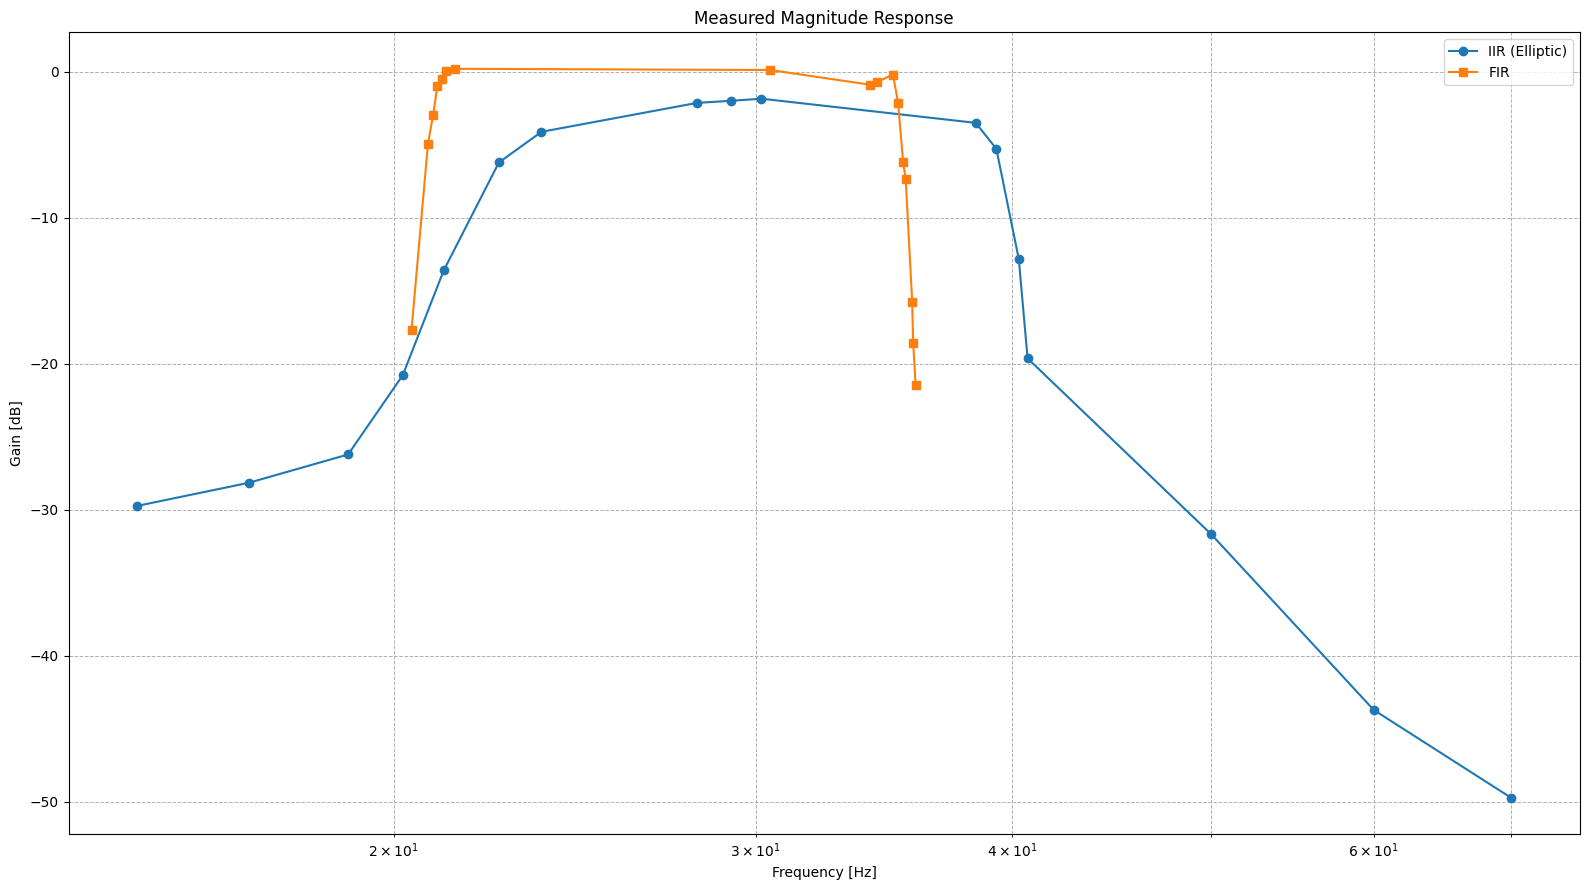

In [3]:
# === Read CSV ===
df = pd.read_csv("TPL2_meas.csv")

# === HTML Table ===
table_html = df.to_html(classes="my-table", border=1, index=False)

html_code = f"""
<button onclick="var tbl = document.getElementById('myTable'); 
                 if(tbl.style.display === 'none') {{
                     tbl.style.display = 'table';
                 }} else {{
                     tbl.style.display = 'none';
                 }}">
  Show/Hide Table
</button>

<div id="myTable" style="display:none;">
  {table_html}
</div>
"""

display(HTML(html_code))

# === Compute magnitude responses ===
# Columns: VinPP,Frec,VoPP,VinPP,Frec,VoPP
vin_iir = df.iloc[1:, 0].astype(float)
freq_iir = df.iloc[1:, 1].astype(float)
vout_iir = df.iloc[1:, 2].astype(float)

vin_fir = df.iloc[1:, 3].astype(float)
freq_fir = df.iloc[1:, 4].astype(float)
vout_fir = df.iloc[1:, 5].astype(float)

gain_iir = 20 * np.log10(vout_iir / vin_iir)
gain_fir = 20 * np.log10(vout_fir / vin_fir)

# === Plot ===
plt.figure(figsize=(16, 9))
plt.semilogx(freq_iir, gain_iir, "o-", label="IIR (Elliptic)")
plt.semilogx(freq_fir, gain_fir, "s-", label="FIR")

plt.title("Measured Magnitude Response")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Gain [dB]")
plt.grid(True, which="both", linestyle="--", linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()

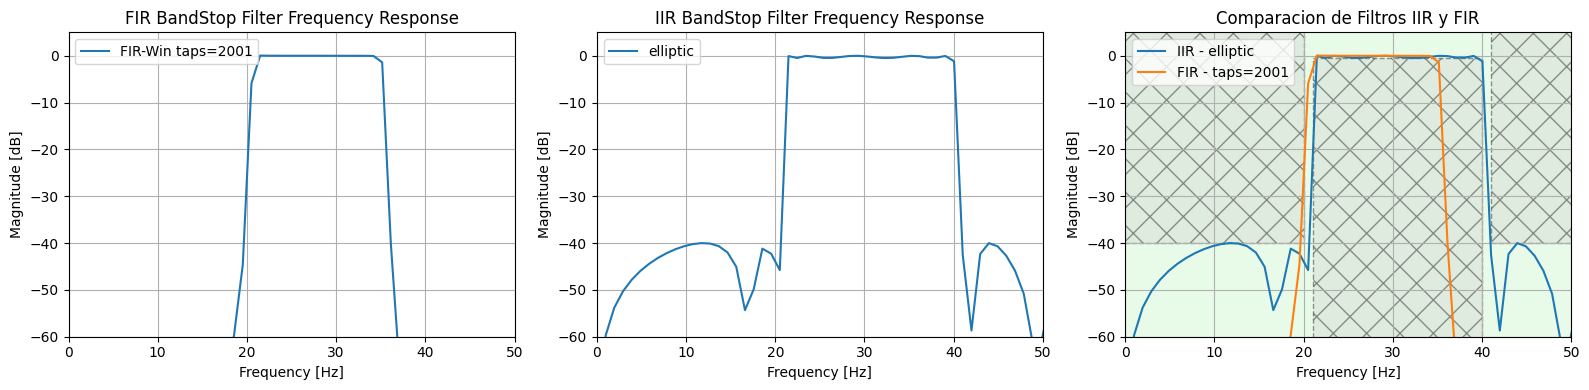

In [4]:
# Filtro FIR
# Parametros del filtro
ripple_db = 0.5  # Ripple en dB
atten_db = 40  # Atenuacion en dB

# Plantilla BandStop
fs1 = 20  # Hz
fp1 = 21  # Hz
fp2 = 35  # Hz
fs2 = 36  # Hz

# Parametros del sistema
fs = 1000  # Hz
nyq = fs / 2

# Filtro IIR

taps = 2001
b = sig.firwin2(
    taps,
    freq=(0, fs1, fp1, fp2, fs2, nyq),
    gain=(0, 0, 1, 1, 0, 0),
    window=("kaiser", 0),
    fs=fs,
)
a = 1.0
w_fir, h_fir = sig.freqz(b, a, fs=fs)

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(16, 4))

# Plot FIR filter
ax1.plot(w_fir, 20 * np.log10(np.abs(h_fir)), label=f"FIR-Win taps={taps}")
ax1.set_title("FIR BandStop Filter Frequency Response")
ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel("Magnitude [dB]")
ax1.legend()
ax1.grid()
ax1.axis([0, 50, -60, 5])

# IIR filter design

# Plantilla BandStop
fs1 = 20  # Hz
fp1 = 21  # Hz
fp2 = 40  # Hz
fs2 = 41  # Hz

wp = np.array([fp1, fp2])
ws = np.array([fs1, fs2])
sos_iir = sig.iirdesign(
    wp=wp,
    ws=ws,
    gpass=ripple_db,
    gstop=atten_db,
    analog=False,
    ftype="elliptic",
    fs=fs,
    output="sos",
)
w_iir, h_iir = sig.freqz_sos(sos_iir, fs=fs)

# Plot IIR filter
ax2.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="elliptic")
ax2.set_title("IIR BandStop Filter Frequency Response")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Magnitude [dB]")
ax2.legend()
ax2.grid()
ax2.axis([0, 50, -60, 5])

# Plot Junto a la plantilla
ax3.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="IIR - elliptic")
ax3.plot(w_fir, 20 * np.log10(np.abs(h_fir)), label=f"FIR - taps={taps}")
ax3.set_title("Comparacion de Filtros IIR y FIR")
ax3.set_xlabel("Frequency [Hz]")
ax3.set_ylabel("Magnitude [dB]")
ax3.legend()
ax3.grid()
plot_plantilla(
    filter_type="bandpass",
    fpass=(fp1, fp2),
    fstop=(fs1, fs2),
    ripple=ripple_db,
    attenuation=atten_db,
    fs=fs,
)
ax3.axis([0, 50, -60, 5])

plt.tight_layout()
plt.show()

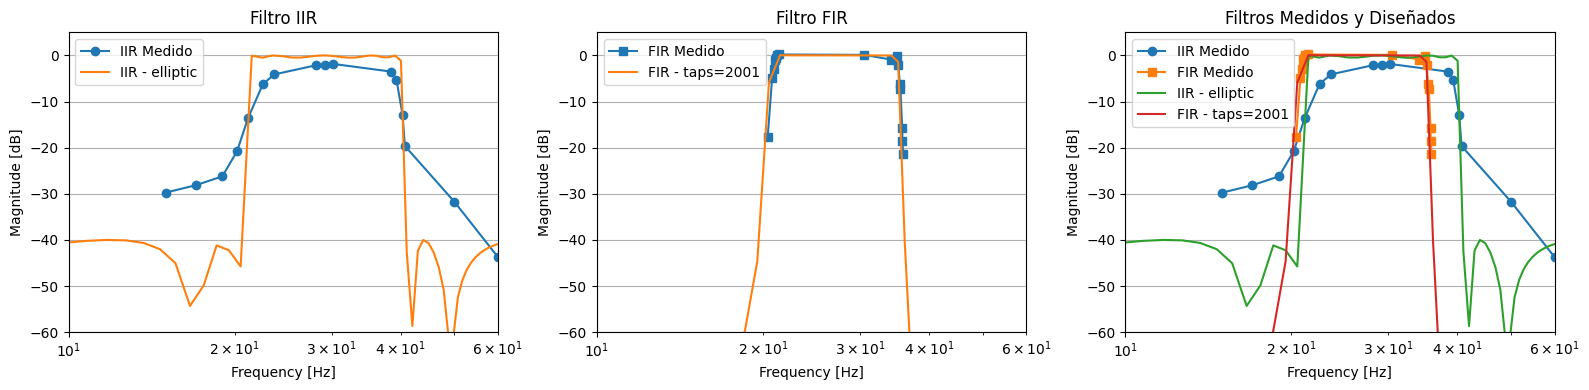

In [5]:
# Plot Junto a los Filtros medidos
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(16, 4))

ax1.semilogx(freq_iir, gain_iir, "o-", label="IIR Medido")
ax1.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="IIR - elliptic")
ax1.set_title("Filtro IIR")
ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel("Magnitude [dB]")
ax1.legend()
ax1.grid()
ax1.axis([10, 60, -60, 5])

ax2.semilogx(freq_fir, gain_fir, "s-", label="FIR Medido")
ax2.plot(w_fir, 20 * np.log10(np.abs(h_fir)), label=f"FIR - taps={taps}")
ax2.set_title("Filtro FIR")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Magnitude [dB]")
ax2.legend()
ax2.grid()
ax2.axis([10, 60, -60, 5])

ax3.semilogx(freq_iir, gain_iir, "o-", label="IIR Medido")
ax3.semilogx(freq_fir, gain_fir, "s-", label="FIR Medido")
ax3.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="IIR - elliptic")
ax3.plot(w_fir, 20 * np.log10(np.abs(h_fir)), label=f"FIR - taps={taps}")
ax3.set_title("Filtros Medidos y Diseñados")
ax3.set_xlabel("Frequency [Hz]")
ax3.set_ylabel("Magnitude [dB]")
ax3.legend()
ax3.grid()
ax3.axis([10, 60, -60, 5])

plt.tight_layout()
plt.show()

## Comentarios de los Resultados Obtenidos

Se observa una buena concordancia entre los resultados simulados y experimentales, no obstante, hay una atenuación en la zona de paso del filtro IIR que no se había previsto en la simulación. No se pudo determinar la causa de esta atenuación, ya que con el filtro FIR no se observó este comportamiento.

## Analizador de Audio

Se emplea un analizador de audio para corroborar los resultados obtenidos manualmente. Se observa una buena concordancia entre ambos métodos.

Durante la medición se aumentaron las frecuencias de corte y stop para poder tener un mejor rango de medición con el equipo disponible. Se el ancho de la banda de paso pero se movió la frecuencia central de manera experimental. 

Hay una discrepancia entre los resultados obtenidos con el analizador de audio y los obtenidos manualmente, hay como un corrimiento en frecuencia. El ancho de la banda de paso es igual, cambia la frecuencia central. No se pudo determinar la causa de este corrimiento.

## Filtro FIR

<div align=center>

![Filtro FIR](imgs/FIR.jpeg)

</div>

## Filtro IIR

<div align=center>

![Filtro IIR](imgs/IIR.jpeg)

</div>

# Conclusiones y Comentarios Finales

Tras diseñar y simular con éxito el filtro digital a partir de una plantilla, se llevó a la práctica el circuito utilizando un microcontrolador STM32 NUCLEO-64. Se implementaron tanto el filtro FIR como el IIR utilizando la librería CMSIS-DSP, lo que facilitó el proceso de desarrollo.

Para verificar el correcto funcionamiento del filtro, se empleó un generador de señales de frecuencia variable junto con un osciloscopio, permitiendo realizar un barrido en frecuencia. De esta forma, se obtuvo la magnitud de la señal, datos que fueron transferidos al notebook para elaborar los gráficos correspondientes.

Finalmente, se utilizó un analizador de audio que realiza el barrido en frecuencia de forma automática, proporcionando directamente los gráficos.

Las mediciones obtenidas mediante el osciloscopio y el analizador de audio concuerdan con los resultados de las simulaciones realizadas previamente en cuanto al ancho de la banda de paso, lo que confirma la validez del diseño y el correcto desempeño del filtro en la práctica. Hay una discrepancia en la frecuencia central entre ambos métodos de medición, pero no se pudo determinar la causa de este corrimiento. Y además, se observó una atenuación en la zona de paso del filtro IIR que no se había previsto en la simulación, cuya causa tampoco se pudo determinar.